# Credit Risk Model Development - Section 1: Data Pipeline & Feature Engineering

This section establishes the analytical foundation for the A/B test. Working with the Home Credit Default Risk dataset (307K loan applicants), we construct a domain-driven feature set, address class imbalance, and produce a clean stratified train/test split for model training.

**Dataset:** [Home Credit Default Risk](https://www.kaggle.com/c/home-credit-default-risk) | Kaggle  
**Output:** Processed training and test sets saved to CSV for downstream modeling.

---
## 1.1 Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# Make all plots look clean
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('All libraries imported successfully!')

All libraries imported successfully!


---
## Load the dataset

Make sure `application_train.csv` is inside your project folder.
If it's in a subfolder, update the path below (e.g. `'data/application_train.csv'`).

In [5]:
df = pd.read_csv(r'C:\Users\hanto\OneDrive\Desktop\Siqi Chen Projects\ML\credit_risk_ab_test\Credit-Risk-A-B-Test-Logistic-Regression-vs-LightGBM\Data\application_train.csv')

print(f'Dataset shape: {df.shape}')
print(f'Rows (loan applicants): {df.shape[0]:,}')
print(f'Columns (features): {df.shape[1]}')
df.head()

Dataset shape: (307511, 122)
Rows (loan applicants): 307,511
Columns (features): 122


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


---
## 1.2 Data Ingestion

The primary training file contains 307,511 loan applications with 122 features spanning applicant demographics, credit bureau data, and loan characteristics. The target variable (`TARGET`) indicates whether an applicant defaulted within the loan term.

Target variable distribution:
  Repaid (0): 282,686 (91.9%)
  Defaulted (1): 24,825 (8.1%)

NOTE: The dataset is heavily imbalanced — far more repaid than defaulted.
We will fix this in Cell 9 using SMOTE.


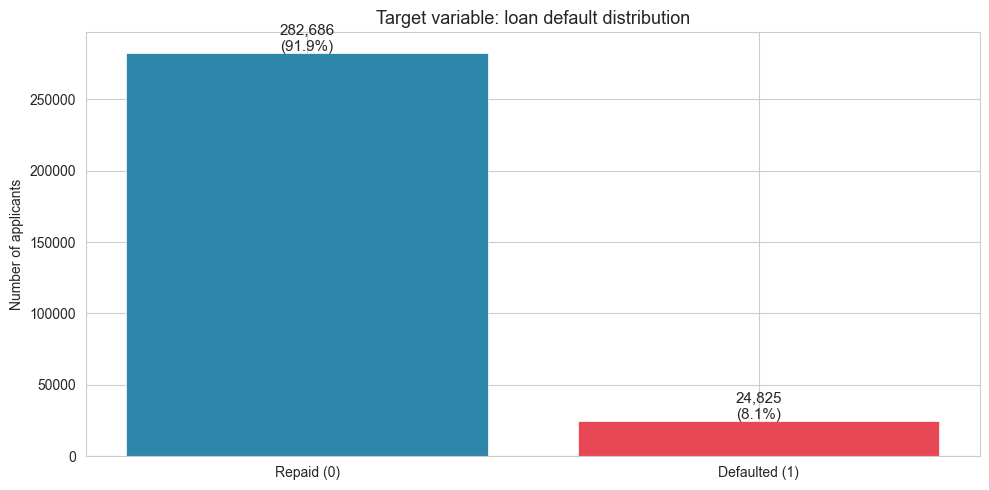

In [6]:
target_counts = df['TARGET'].value_counts()
target_pct = df['TARGET'].value_counts(normalize=True) * 100

print('Target variable distribution:')
print(f'  Repaid (0): {target_counts[0]:,} ({target_pct[0]:.1f}%)')
print(f'  Defaulted (1): {target_counts[1]:,} ({target_pct[1]:.1f}%)')
print()
print('NOTE: The dataset is heavily imbalanced — far more repaid than defaulted.')
print('We will fix this in Cell 9 using SMOTE.')

# Plot the distribution
fig, ax = plt.subplots()
ax.bar(['Repaid (0)', 'Defaulted (1)'], target_counts.values,
       color=['#2E86AB', '#E84855'], edgecolor='white', linewidth=0.5)
ax.set_title('Target variable: loan default distribution', fontsize=13)
ax.set_ylabel('Number of applicants')
for i, v in enumerate(target_counts.values):
    ax.text(i, v + 1000, f'{v:,}\n({target_pct.values[i]:.1f}%)',
            ha='center', fontsize=11)
plt.tight_layout()
plt.show()

---
## Check missing values

Many real-world datasets have missing data. We need to understand how much is missing before we can clean it.

Columns with missing values: 67 out of 122

Top 20 columns with most missing data:
                          missing_count  missing_pct
COMMONAREA_MEDI                  214865    69.872297
COMMONAREA_MODE                  214865    69.872297
COMMONAREA_AVG                   214865    69.872297
NONLIVINGAPARTMENTS_MODE         213514    69.432963
NONLIVINGAPARTMENTS_MEDI         213514    69.432963
NONLIVINGAPARTMENTS_AVG          213514    69.432963
FONDKAPREMONT_MODE               210295    68.386172
LIVINGAPARTMENTS_AVG             210199    68.354953
LIVINGAPARTMENTS_MEDI            210199    68.354953
LIVINGAPARTMENTS_MODE            210199    68.354953
FLOORSMIN_MEDI                   208642    67.848630
FLOORSMIN_MODE                   208642    67.848630
FLOORSMIN_AVG                    208642    67.848630
YEARS_BUILD_MODE                 204488    66.497784
YEARS_BUILD_MEDI                 204488    66.497784
YEARS_BUILD_AVG                  204488    66.497784
OWN_CAR_AGE     

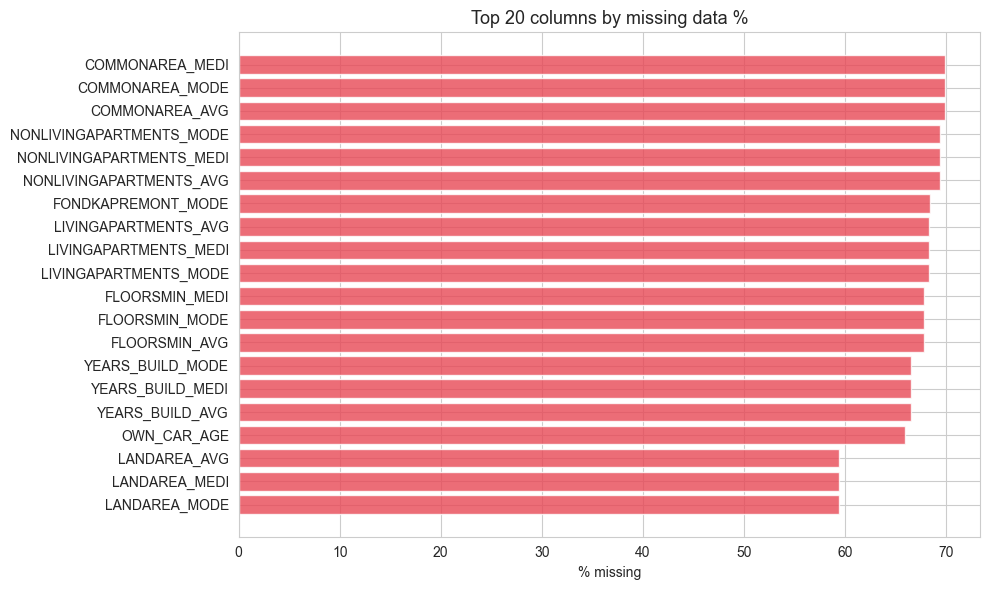

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).query('missing_count > 0').sort_values('missing_pct', ascending=False)

print(f'Columns with missing values: {len(missing_df)} out of {df.shape[1]}')
print()
print('Top 20 columns with most missing data:')
print(missing_df.head(20).to_string())

# Plot top 20 missing columns
top_missing = missing_df.head(20)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_missing.index[::-1], top_missing['missing_pct'][::-1], color='#E84855', alpha=0.8)
ax.set_xlabel('% missing')
ax.set_title('Top 20 columns by missing data %', fontsize=13)
plt.tight_layout()
plt.show()

---
## 1.3 Target Variable Analysis

`TARGET = 1` - applicant defaulted on the loan  
`TARGET = 0` - applicant repaid successfully

The distribution of this variable directly informs the class imbalance strategy applied in Section 1.7.

In [8]:
# These are the features we will use for modeling
FEATURES = [
    # Applicant profile
    'AMT_INCOME_TOTAL',      # Annual income
    'AMT_CREDIT',            # Loan amount
    'AMT_ANNUITY',           # Annual loan payment
    'AMT_GOODS_PRICE',       # Price of goods the loan is for
    'DAYS_BIRTH',            # Age (in days, negative = days before application)
    'DAYS_EMPLOYED',         # Employment duration (negative = currently employed)
    'DAYS_ID_PUBLISH',       # Days since ID was last changed
    'DAYS_REGISTRATION',     # Days since applicant changed registration

    # Credit bureau info
    'EXT_SOURCE_1',          # External credit score 1 (bureau)
    'EXT_SOURCE_2',          # External credit score 2
    'EXT_SOURCE_3',          # External credit score 3

    # Loan characteristics
    'NAME_CONTRACT_TYPE',    # Cash vs revolving
    'CODE_GENDER',           # Gender
    'FLAG_OWN_CAR',          # Owns a car
    'FLAG_OWN_REALTY',       # Owns real estate
    'CNT_CHILDREN',          # Number of children
    'NAME_INCOME_TYPE',      # Income type (employed, pensioner, etc.)
    'NAME_EDUCATION_TYPE',   # Education level
    'NAME_FAMILY_STATUS',    # Marital status
    'REGION_RATING_CLIENT',  # Region risk rating (1=best, 3=worst)

    # Target
    'TARGET'
]

df_model = df[FEATURES].copy()
print(f'Working dataset shape: {df_model.shape}')
print(f'\nFeature types:')
print(df_model.dtypes)

Working dataset shape: (307511, 21)

Feature types:
AMT_INCOME_TOTAL        float64
AMT_CREDIT              float64
AMT_ANNUITY             float64
AMT_GOODS_PRICE         float64
DAYS_BIRTH                int64
DAYS_EMPLOYED             int64
DAYS_ID_PUBLISH           int64
DAYS_REGISTRATION       float64
EXT_SOURCE_1            float64
EXT_SOURCE_2            float64
EXT_SOURCE_3            float64
NAME_CONTRACT_TYPE          str
CODE_GENDER                 str
FLAG_OWN_CAR                str
FLAG_OWN_REALTY             str
CNT_CHILDREN              int64
NAME_INCOME_TYPE            str
NAME_EDUCATION_TYPE         str
NAME_FAMILY_STATUS          str
REGION_RATING_CLIENT      int64
TARGET                    int64
dtype: object


---
## Feature engineering

Raw columns are rarely the best predictors. We create **new features** that directly capture financial risk concepts — this is where domain knowledge (your Fannie Mae background) makes a real difference.

In [9]:
# --- Ratio features (capture relative risk, not just raw amounts) ---

# Debt-to-Income ratio: how much loan vs income (higher = riskier)
df_model['DEBT_TO_INCOME'] = df_model['AMT_CREDIT'] / (df_model['AMT_INCOME_TOTAL'] + 1)

# Payment-to-Income ratio: annual payment burden relative to income
df_model['PAYMENT_TO_INCOME'] = df_model['AMT_ANNUITY'] / (df_model['AMT_INCOME_TOTAL'] + 1)

# Loan-to-Value ratio: how much loan vs goods price (higher = less collateral)
df_model['LOAN_TO_VALUE'] = df_model['AMT_CREDIT'] / (df_model['AMT_GOODS_PRICE'] + 1)

# Credit term (months): how long is the loan?
df_model['CREDIT_TERM'] = df_model['AMT_CREDIT'] / (df_model['AMT_ANNUITY'] + 1)

# --- Age and employment features ---

# Convert days to years (DAYS_BIRTH is negative in the dataset)
df_model['AGE_YEARS'] = (-df_model['DAYS_BIRTH']) / 365

# Employment years (DAYS_EMPLOYED is negative if currently employed)
# 365243 is a placeholder for retired/unemployed — replace with 0
df_model['EMPLOYED_YEARS'] = df_model['DAYS_EMPLOYED'].replace(365243, 0)
df_model['EMPLOYED_YEARS'] = (-df_model['EMPLOYED_YEARS']) / 365
df_model['EMPLOYED_YEARS'] = df_model['EMPLOYED_YEARS'].clip(lower=0)

# Employment stability: employed years relative to age
df_model['EMPLOYMENT_TO_AGE'] = df_model['EMPLOYED_YEARS'] / (df_model['AGE_YEARS'] + 1)

# --- External credit score features ---

# Average of all three external credit scores (combined bureau signal)
df_model['EXT_SOURCE_MEAN'] = df_model[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis=1)

# Minimum score (worst bureau signal — captures downside risk)
df_model['EXT_SOURCE_MIN'] = df_model[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].min(axis=1)

print('New engineered features created:')
new_features = ['DEBT_TO_INCOME', 'PAYMENT_TO_INCOME', 'LOAN_TO_VALUE',
                'CREDIT_TERM', 'AGE_YEARS', 'EMPLOYED_YEARS',
                'EMPLOYMENT_TO_AGE', 'EXT_SOURCE_MEAN', 'EXT_SOURCE_MIN']
print(df_model[new_features].describe().round(3).to_string())

New engineered features created:
       DEBT_TO_INCOME  PAYMENT_TO_INCOME  LOAN_TO_VALUE  CREDIT_TERM   AGE_YEARS  EMPLOYED_YEARS  EMPLOYMENT_TO_AGE  EXT_SOURCE_MEAN  EXT_SOURCE_MIN
count      307511.000         307499.000     307233.000   307499.000  307511.000      307511.000         307511.000       307339.000      307339.000
mean            3.958              0.181          1.123       21.611      43.937           5.356              0.125            0.509           0.400
std             2.690              0.095          0.124        7.824      11.956           6.321              0.132            0.150           0.187
min             0.005              0.000          0.150        8.036      20.518           0.000              0.000            0.000           0.000
25%             2.019              0.115          1.000       15.614      34.008           0.792              0.021            0.414           0.254
50%             3.265              0.163          1.119       19.999     

---
## 1.4 Missing Value Assessment

Systematic profiling of missingness across all 122 features. Columns with high missingness rates are flagged; the imputation strategy (median for numeric, mode-fill for categorical) is applied uniformly in Section 1.6 to avoid data leakage from test set statistics.

In [10]:
# Identify categorical (text) columns
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
num_cols = df_model.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != 'TARGET']

print(f'Categorical columns to encode: {cat_cols}')
print(f'Numeric columns to fill: {len(num_cols)}')

# Fill missing numeric values with median (robust to outliers)
for col in num_cols:
    median_val = df_model[col].median()
    df_model[col] = df_model[col].fillna(median_val)

# Encode categorical columns as numbers using LabelEncoder
le = LabelEncoder()
for col in cat_cols:
    df_model[col] = df_model[col].fillna('Unknown')
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# Confirm no missing values remain
remaining_missing = df_model.isnull().sum().sum()
print(f'\nTotal missing values remaining: {remaining_missing}')
print('Dataset is clean and ready for modeling!')

Categorical columns to encode: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS']
Numeric columns to fill: 22

Total missing values remaining: 0
Dataset is clean and ready for modeling!


---
## Explore key features vs default rate

Before modeling, let's visually confirm that our engineered features actually separate defaulters from non-defaulters. This is your EDA (Exploratory Data Analysis).

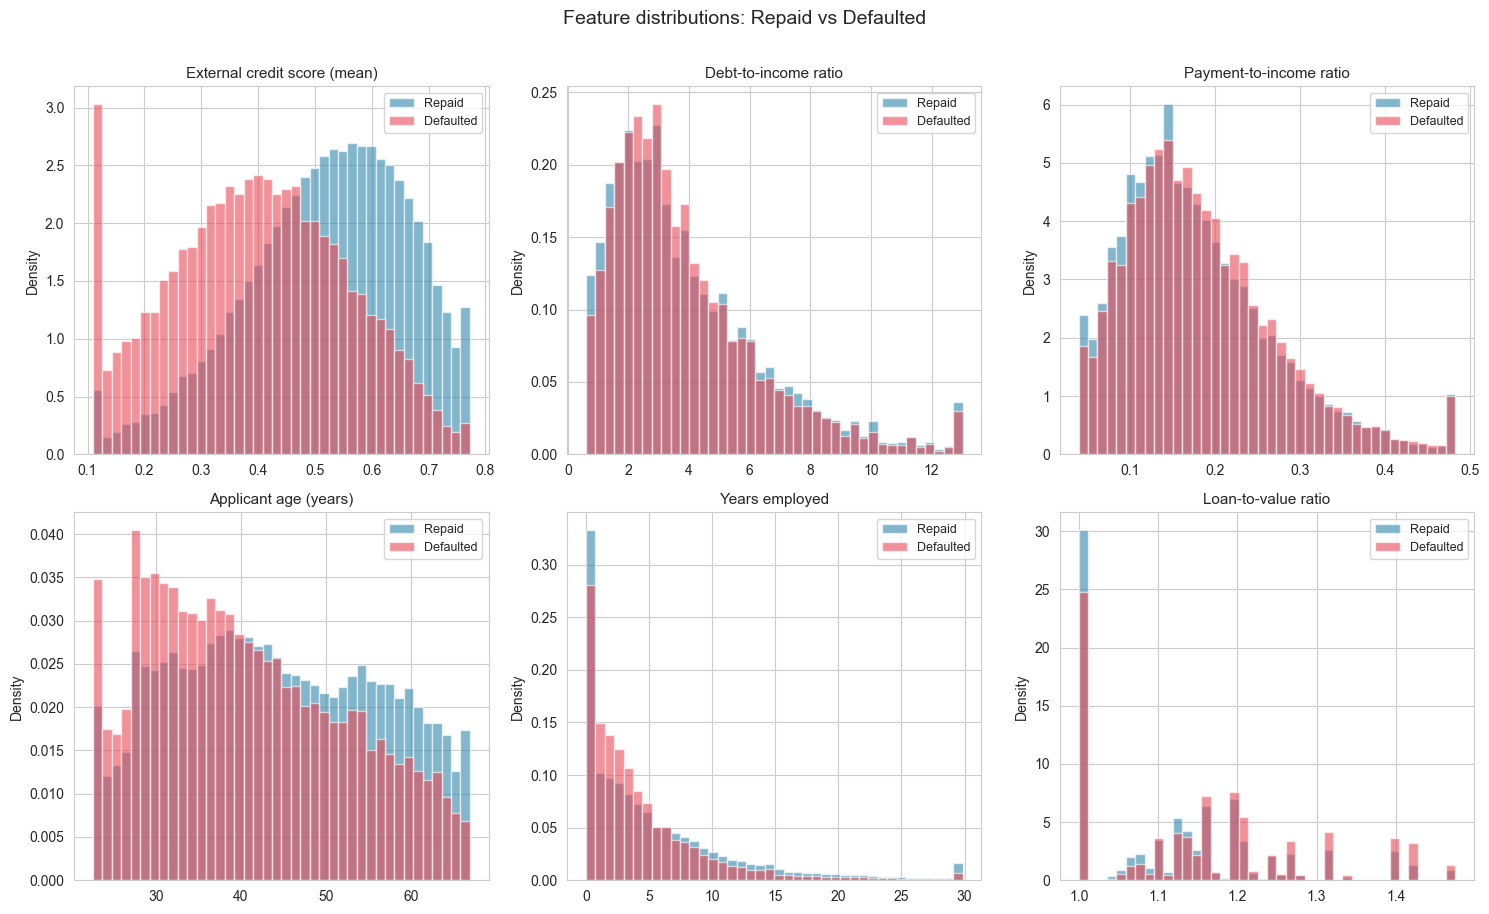

Interpretation:
- EXT_SOURCE_MEAN: defaulters have lower credit scores (distributions clearly separated)
- DEBT_TO_INCOME: defaulters tend to have higher debt burden
- AGE_YEARS: younger applicants default more often


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

plot_features = [
    ('EXT_SOURCE_MEAN', 'External credit score (mean)'),
    ('DEBT_TO_INCOME', 'Debt-to-income ratio'),
    ('PAYMENT_TO_INCOME', 'Payment-to-income ratio'),
    ('AGE_YEARS', 'Applicant age (years)'),
    ('EMPLOYED_YEARS', 'Years employed'),
    ('LOAN_TO_VALUE', 'Loan-to-value ratio'),
]

for ax, (feat, label) in zip(axes, plot_features):
    repaid = df_model[df_model['TARGET'] == 0][feat]
    defaulted = df_model[df_model['TARGET'] == 1][feat]

    # Clip extreme outliers for cleaner plots
    low, high = df_model[feat].quantile(0.01), df_model[feat].quantile(0.99)
    repaid = repaid.clip(low, high)
    defaulted = defaulted.clip(low, high)

    ax.hist(repaid, bins=40, alpha=0.6, color='#2E86AB', label='Repaid', density=True)
    ax.hist(defaulted, bins=40, alpha=0.6, color='#E84855', label='Defaulted', density=True)
    ax.set_title(label, fontsize=11)
    ax.legend(fontsize=9)
    ax.set_ylabel('Density')

plt.suptitle('Feature distributions: Repaid vs Defaulted', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('Interpretation:')
print('- EXT_SOURCE_MEAN: defaulters have lower credit scores (distributions clearly separated)')
print('- DEBT_TO_INCOME: defaulters tend to have higher debt burden')
print('- AGE_YEARS: younger applicants default more often')

---
## 1.5 Feature Selection

Of the 122 raw features, 20 are selected based on financial domain relevance and signal strength. Selection prioritizes features that directly capture credit risk concepts - income capacity, debt burden, repayment history, and external credit assessments - over raw administrative identifiers.

In [12]:
# Define features (X) and target (y)
DROP_COLS = ['TARGET', 'DAYS_BIRTH', 'DAYS_EMPLOYED']  # raw versions replaced by engineered ones
feature_cols = [c for c in df_model.columns if c not in DROP_COLS]

X = df_model[feature_cols]
y = df_model['TARGET']

# Stratified split: preserves class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,      # set seed so results are reproducible
    stratify=y            # ensure same default rate in train & test
)

print('Train/test split complete:')
print(f'  Training set:  {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'  Test set:      {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'  Features:      {X_train.shape[1]}')
print()
print(f'Default rate in train: {y_train.mean()*100:.2f}%')
print(f'Default rate in test:  {y_test.mean()*100:.2f}%')
print('(Should be almost identical — confirms stratify worked)')

Train/test split complete:
  Training set:  215,257 rows (70%)
  Test set:      92,254 rows (30%)
  Features:      27

Default rate in train: 8.07%
Default rate in test:  8.07%
(Should be almost identical — confirms stratify worked)


---
## Handle class imbalance with SMOTE

Only ~8% of loans defaulted, so if we train as-is, models will just predict 'repaid' for everyone and be 92% accurate, but this is useless.

**SMOTE** (Synthetic Minority Oversampling Technique) creates synthetic defaulter examples to balance the training set. We only apply it to **training data**

In [13]:
print('Before SMOTE:')
print(f'  Repaid:    {(y_train == 0).sum():,}')
print(f'  Defaulted: {(y_train == 1).sum():,}')
print(f'  Default rate: {y_train.mean()*100:.2f}%')

smote = SMOTE(random_state=42, sampling_strategy=0.3)
# sampling_strategy=0.3 means defaulters will be 30% of repaid count
# (full 50/50 balance can sometimes hurt model performance on real data)

X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print('\nAfter SMOTE:')
print(f'  Repaid:    {(y_train_bal == 0).sum():,}')
print(f'  Defaulted: {(y_train_bal == 1).sum():,}')
print(f'  Default rate: {y_train_bal.mean()*100:.2f}%')
print()
print('Test set is NOT resampled — it stays as the real-world distribution.')

Before SMOTE:
  Repaid:    197,880
  Defaulted: 17,377
  Default rate: 8.07%

After SMOTE:
  Repaid:    197,880
  Defaulted: 59,364
  Default rate: 23.08%

Test set is NOT resampled — it stays as the real-world distribution.


---
## 1.6 Feature Engineering

Nine domain-driven features are constructed from raw columns to capture financial risk relationships that raw values alone cannot express. These ratios align with standard underwriting metrics used in mortgage and consumer credit analysis:

| Feature | Computation | Risk rationale |
|---|---|---|
| `DEBT_TO_INCOME` | AMT_CREDIT / AMT_INCOME | Measures total loan burden relative to annual earnings |
| `PAYMENT_TO_INCOME` | AMT_ANNUITY / AMT_INCOME | Periodic repayment affordability |
| `LOAN_TO_VALUE` | AMT_CREDIT / AMT_GOODS_PRICE | Collateral coverage — higher LTV signals lower security |
| `CREDIT_TERM` | AMT_CREDIT / AMT_ANNUITY | Effective loan duration in months |
| `AGE_YEARS` | −DAYS_BIRTH / 365 | Applicant age at time of application |
| `EMPLOYED_YEARS` | −DAYS_EMPLOYED / 365 | Continuous employment duration |
| `EMPLOYMENT_TO_AGE` | EMPLOYED_YEARS / AGE_YEARS | Career stability relative to life stage |
| `EXT_SOURCE_MEAN` | Mean(EXT_SOURCE_1,2,3) | Composite external bureau credit signal |
| `EXT_SOURCE_MIN` | Min(EXT_SOURCE_1,2,3) | Worst-case bureau signal — captures tail credit risk |

In [14]:
# Save train and test sets
X_train_bal.to_csv('X_train.csv', index=False)
y_train_bal.to_csv('y_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

# Save feature column names for Phase 2
with open('feature_cols.txt', 'w') as f:
    f.write('\n'.join(feature_cols))

print('Files saved to your project folder:')
print('  X_train.csv      — training features (SMOTE balanced)')
print('  y_train.csv      — training labels')
print('  X_test.csv       — test features (real-world distribution)')
print('  y_test.csv       — test labels')
print('  feature_cols.txt — list of feature names')
print()
print('Phase 1 complete! You are ready for Phase 2 — Model Development.')

Files saved to your project folder:
  X_train.csv      — training features (SMOTE balanced)
  y_train.csv      — training labels
  X_test.csv       — test features (real-world distribution)
  y_test.csv       — test labels
  feature_cols.txt — list of feature names

Phase 1 complete! You are ready for Phase 2 — Model Development.


---
## Section 1 Summary

| Step | What we did |
|---|---|
| Loaded data | 300K+ loan applicants, 120+ columns |
| Explored target | ~8% default rate — heavily imbalanced |
| Selected features | 20 financially meaningful columns |
| Engineered features | Debt-to-income, payment-to-income, LTV, credit term, age, employment stability, bureau score aggregates |
| Cleaned data | Filled missing values with medians, encoded categorical columns |
| Visualized | Confirmed engineered features separate defaulters from non-defaulters |
| Split data | 70% train / 30% test with stratification |
| Balanced classes | Applied SMOTE to training set only |
| Saved outputs | CSV files ready for Phase 2 |

**Next: Section 2 - Build Model A (Logistic Regression scorecard) and Model B (LightGBM)**